# Web Unlocker 核心功能深度测试

本 Notebook 用真实请求逐项演示四项能力：**网页截图、HTML 转 Markdown、地理定位、移动端 User-Agent**。


测试证据统一保存到 `results/`，最后一个单元会生成汇总表和可直接用于写文章的结论文件。

## 0. 初始化与安全检查

这里加载配置、创建结果目录，并仅展示脱敏后的凭据信息。

In [1]:
from pathlib import Path
import json
import re

import pandas as pd
from IPython.display import display, HTML, Image, Markdown
from PIL import Image as PILImage

from web_unlocker_testkit import (
    load_config, request_unlock, request_native_user_agent,
    parse_json_response, curl_preview, native_curl_preview, write_results
)

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
for old_file in RESULTS_DIR.iterdir():
    if old_file.is_file():
        old_file.unlink()
config = load_config()
results = []

display(HTML('<h3>配置检查</h3>'))
display(pd.DataFrame([config.masked()]).T.rename(columns={0: '当前值'}))
assert config.ready, '请先在 .env 中填写 BRIGHTDATA_API_KEY 和 BRIGHTDATA_ZONE'
print('✅ 配置已就绪，完整密钥不会出现在 Notebook 输出中。')

,当前值
api_key,3cd1...9933
zone,web_unlocker1
endpoint,https://api.brightdata.com/request
timeout,180
screenshot_url,https://example.com
markdown_url,https://en.wikipedia.org/wiki/Web_scraping
geo_url,https://geo.brdtest.com/mygeo.json
ua_url,https://httpbin.org/user-agent
ready,True


✅ 配置已就绪，完整密钥不会出现在 Notebook 输出中。


## 1. 基线：获取原始 HTML

先抓取与 Markdown 测试相同的页面，作为后续格式转换的对照组。

In [2]:
baseline_response, baseline_result = request_unlock(
    config,
    name='HTML 基线',
    url=config.markdown_url,
    output_path=RESULTS_DIR / '01_baseline.html',
)
results.append(baseline_result)

print(curl_preview(baseline_result.request_payload, 'results/01_baseline.html'))
print()
print(baseline_result)
baseline_html = baseline_response.text if baseline_response is not None else ''
print('\nHTML 前 800 个字符：\n')
print(baseline_html[:800])

curl --request POST \
  --url https://api.brightdata.com/request \
  --header "Authorization: Bearer ${BRIGHTDATA_API_KEY}" \
  --header "Content-Type: application/json" \
  --data '{"zone": "web_unlocker1", "url": "https://en.wikipedia.org/wiki/Web_scraping", "format": "raw", "debug": true}' \
  --output results/01_baseline.html

RequestResult(name='HTML 基线', ok=True, status_code=200, elapsed_seconds=25.044, content_type='text/html; charset=UTF-8', response_bytes=231440, output_file='results\\01_baseline.html', note='OK', request_payload={'zone': 'web_unlocker1', 'url': 'https://en.wikipedia.org/wiki/Web_scraping', 'format': 'raw', 'debug': True}, response_headers={'Content-Type': 'text/html; charset=UTF-8', 'x-brd-debug': 'req_id=hl_2160df40_sbfqrnr6bcs; bytes_up=2668; bytes_down=58449; billed=true; destination_ip=208.80.154.224; used_req_headers=; peer_ip=d2f0e6dbf6dac91ad6c1eb65e3fe3eb88; peer_country=us; render=false'})

HTML 前 800 个字符：

<!DOCTYPE html>
<html class="client-nojs ve

## 2. 功能一：网页截图（Screenshot）

设置 `data_format=screenshot` 后，接口应返回 PNG。这里不仅显示图片，还校验文件签名、图片尺寸和文件大小。

curl --request POST \
  --url https://api.brightdata.com/request \
  --header "Authorization: Bearer ${BRIGHTDATA_API_KEY}" \
  --header "Content-Type: application/json" \
  --data '{"zone": "web_unlocker1", "url": "https://example.com", "format": "raw", "data_format": "screenshot", "debug": true}' \
  --output results/02_screenshot.png

RequestResult(name='网页截图', ok=True, status_code=200, elapsed_seconds=19.456, content_type='application/json', response_bytes=19077, output_file='results\\02_screenshot.png', note='OK', request_payload={'zone': 'web_unlocker1', 'url': 'https://example.com', 'format': 'raw', 'data_format': 'screenshot', 'debug': True}, response_headers={'Content-Type': 'application/json', 'x-brd-debug': 'req_id=hl_2160df40_ny4y3ihqd; bytes_up=2465; bytes_down=5324; billed=true; peer_ip=re180b6544b89d0a71d089cd5b6f3960c; peer_country=us; render=true'})


,格式,尺寸,模式,文件大小
0,PNG,1875 × 822,RGB,18.6 KB


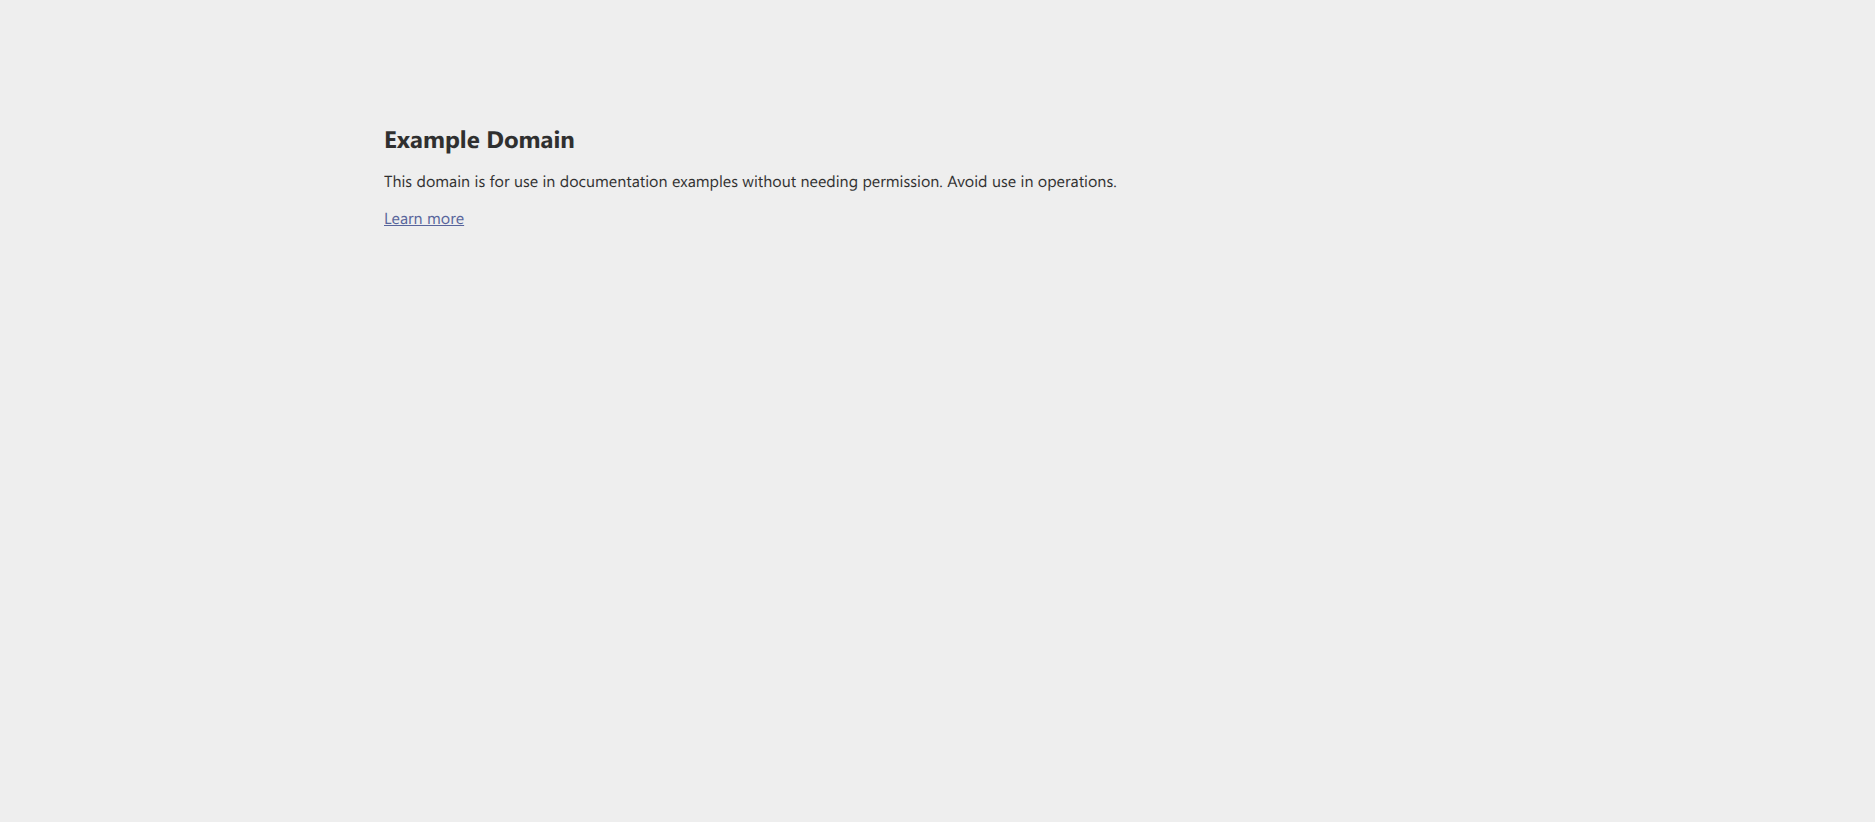

✅ 截图测试通过：返回内容是有效 PNG 文件。


In [3]:
screenshot_path = RESULTS_DIR / '02_screenshot.png'
screenshot_response, screenshot_result = request_unlock(
    config,
    name='网页截图',
    url=config.screenshot_url,
    output_path=screenshot_path,
    data_format='screenshot',
)
results.append(screenshot_result)

print(curl_preview(screenshot_result.request_payload, 'results/02_screenshot.png'))
print()
print(screenshot_result)

if screenshot_result.ok and screenshot_path.exists():
    with PILImage.open(screenshot_path) as image:
        screenshot_info = {
            '格式': image.format,
            '尺寸': f'{image.width} × {image.height}',
            '模式': image.mode,
            '文件大小': f'{screenshot_path.stat().st_size / 1024:.1f} KB',
        }
    display(pd.DataFrame([screenshot_info]))
    display(Image(filename=str(screenshot_path), width=900))
    print('✅ 截图测试通过：返回内容是有效 PNG 文件。')
else:
    print('❌ 截图测试未通过，请查看结果对象和 .error.txt 文件。')

## 3. 功能二：HTML 转 Markdown

设置 `data_format=markdown`，将同一网页直接转换为 Markdown。下面对比 HTML 与 Markdown 的体积、标签数量和文本预览。

In [4]:
markdown_path = RESULTS_DIR / '03_markdown.md'
markdown_response, markdown_result = request_unlock(
    config,
    name='Markdown 转换',
    url=config.markdown_url,
    output_path=markdown_path,
    data_format='markdown',
)
results.append(markdown_result)

markdown_text = markdown_response.text if markdown_response is not None else ''
comparison = pd.DataFrame([
    {
        '格式': '原始 HTML',
        '字符数': len(baseline_html),
        'HTML 标签近似数': len(re.findall(r'<[^>]+>', baseline_html)),
        '文件': 'results/01_baseline.html',
    },
    {
        '格式': 'Markdown',
        '字符数': len(markdown_text),
        'HTML 标签近似数': len(re.findall(r'<[^>]+>', markdown_text)),
        '文件': 'results/03_markdown.md',
    },
])
display(comparison)
print(curl_preview(markdown_result.request_payload, 'results/03_markdown.md'))
print('\nMarkdown 原文前 1500 个字符：\n')
print(markdown_text[:1500])
display(Markdown('### 渲染后的 Markdown 预览\n\n' + markdown_text[:2500]))
if markdown_result.ok:
    print('✅ Markdown 转换测试通过：接口直接返回了可读文本。')

,格式,字符数,HTML 标签近似数,文件
0,原始 HTML,230940,3639,results/01_baseline.html
1,Markdown,62578,0,results/03_markdown.md


curl --request POST \
  --url https://api.brightdata.com/request \
  --header "Authorization: Bearer ${BRIGHTDATA_API_KEY}" \
  --header "Content-Type: application/json" \
  --data '{"zone": "web_unlocker1", "url": "https://en.wikipedia.org/wiki/Web_scraping", "format": "raw", "data_format": "markdown", "debug": true}' \
  --output results/03_markdown.md

Markdown 原文前 1500 个字符：

 Web scraping - Wikipedia                        

[Jump to content](#bodyContent)

 Main menu

Main menu

move to sidebar hide

Navigation

*   [Main page](/wiki/Main_Page "Visit the main page [z]")
*   [Contents](/wiki/Wikipedia:Contents "Guides to browsing Wikipedia")
*   [Current events](/wiki/Portal:Current_events "Articles related to current events")
*   [Random article](/wiki/Special:Random "Visit a randomly selected article [x]")
*   [About Wikipedia](/wiki/Wikipedia:About "Learn about Wikipedia and how it works")
*   [Contact us](//en.wikipedia.org/wiki/Wikipedia:Contact_us "How to contact Wikipedia")


### 渲染后的 Markdown 预览

 Web scraping - Wikipedia                        

[Jump to content](#bodyContent)

 Main menu

Main menu

move to sidebar hide

Navigation

*   [Main page](/wiki/Main_Page "Visit the main page [z]")
*   [Contents](/wiki/Wikipedia:Contents "Guides to browsing Wikipedia")
*   [Current events](/wiki/Portal:Current_events "Articles related to current events")
*   [Random article](/wiki/Special:Random "Visit a randomly selected article [x]")
*   [About Wikipedia](/wiki/Wikipedia:About "Learn about Wikipedia and how it works")
*   [Contact us](//en.wikipedia.org/wiki/Wikipedia:Contact_us "How to contact Wikipedia")

Contribute

*   [Help](/wiki/Help:Contents "Guidance on how to use and edit Wikipedia")
*   [Learn to edit](/wiki/Help:Introduction "Learn how to edit Wikipedia")
*   [Community portal](/wiki/Wikipedia:Community_portal "The hub for editors")
*   [Recent changes](/wiki/Special:RecentChanges "A list of recent changes to Wikipedia [r]")
*   [Upload file](/wiki/Wikipedia:File_upload_wizard "Add images or other media for use on Wikipedia")
*   [Special pages](/wiki/Special:SpecialPages "A list of all special pages [q]")

  [![](/static/images/icons/enwiki-25.svg) ![Wikipedia](/static/images/mobile/copyright/wikipedia-wordmark-en-25.svg) ![The Free Encyclopedia](/static/images/mobile/copyright/wikipedia-tagline-en-25.svg)](/wiki/Main_Page)

[Search](/wiki/Special:Search "Search Wikipedia [f]")

Search

 Appearance

*   [Donate](https://donate.wikimedia.org/?wmf_source=donate&wmf_medium=sidebar&wmf_campaign=en.wikipedia.org&uselang=en)
*   [Create account](/w/index.php?title=Special:CreateAccount&returnto=Web+scraping "You are encouraged to create an account and log in; however, it is not mandatory")
*   [Log in](/w/index.php?title=Special:UserLogin&returnto=Web+scraping "You're encouraged to log in; however, it's not mandatory. [o]")

 Personal tools

*   [Donate](https://donate.wikimedia.org/?wmf_source=donate&wmf_medium=sidebar&wmf_campaign=en.wikipedia.org&uselang=en)
*   [Create account](/w/index.php?title=Special:CreateAccount&returnto=Web+scraping "You are encouraged to create an account and log in; however, it is not mandatory")
*   [Log in](/w/index.php?title=Special:UserLogin&returnto=Web+scraping "You're encouraged to log in; however, it's not mandatory. [o]")

## Contents

move to sidebar hide

*   [
    
    (Top)
    
    ](#)
*   [
    
    1 History
    
    ](#History)
    
*   [
    
    2 Techniques
    
    ](#Techniques)Toggle Techniqu

✅ Markdown 转换测试通过：接口直接返回了可读文本。


## 4. 功能三：地理定位（Geolocation）

保持 URL 和其他参数不变，只切换 `country=jp` 与 `country=us`，验证出口国家、地区、时区和 ASN 是否变化。

In [5]:
geo_rows = []
for country_code, label in [('jp', '日本'), ('us', '美国')]:
    output_path = RESULTS_DIR / f'04_geo_{country_code}.json'
    response, result = request_unlock(
        config,
        name=f'地理定位-{label}',
        url=config.geo_url,
        output_path=output_path,
        country=country_code,
    )
    results.append(result)
    data = parse_json_response(response)
    geo = data.get('geo', {}) if isinstance(data.get('geo', {}), dict) else {}
    asn = data.get('asn', {}) if isinstance(data.get('asn', {}), dict) else {}
    geo_rows.append({
        '请求地区': label,
        'country 参数': country_code,
        '返回国家': data.get('country'),
        '城市': geo.get('city'),
        '地区': geo.get('region_name') or geo.get('region'),
        '时区': geo.get('tz'),
        'ASN': asn.get('asnum'),
        '运营商': asn.get('org_name'),
        'HTTP': result.status_code,
        '耗时(s)': result.elapsed_seconds,
    })

geo_df = pd.DataFrame(geo_rows)
display(geo_df)
jp_ok = str(geo_df.loc[geo_df['country 参数'] == 'jp', '返回国家'].iloc[0]).upper() == 'JP'
us_ok = str(geo_df.loc[geo_df['country 参数'] == 'us', '返回国家'].iloc[0]).upper() == 'US'
print('✅ 地理定位测试通过：JP 与 US 均匹配请求地区。' if jp_ok and us_ok else '⚠️ 请检查返回国家字段。')

,请求地区,country 参数,返回国家,城市,地区,时区,ASN,运营商,HTTP,耗时(s)
0,日本,jp,JP,Tokyo,Tokyo,Asia/Tokyo,203020,HostRoyale Technologies Pvt Ltd,200,8.100
1,美国,us,US,Piscataway,New Jersey,America/New_York,20473,"The Constant Company, LLC",200,15.965


✅ 地理定位测试通过：JP 与 US 均匹配请求地区。


## 5. 功能四：移动端 User-Agent

该修饰符属于 Native Access 的代理用户名，而不是 REST API 的 zone 名称。Notebook 会通过账户 API 临时读取 Native Access 凭据，分别请求桌面端和追加 `-ua-mobile` 的移动端；完整凭据不会写入输出。

In [6]:
ua_rows = []
ua_cases = [
    ('桌面端', False, '05_ua_desktop.json'),
    ('移动端', True, '05_ua_mobile.json'),
]
for label, is_mobile, filename in ua_cases:
    response, result = request_native_user_agent(
        config,
        name=f'User-Agent-{label}',
        output_path=RESULTS_DIR / filename,
        mobile=is_mobile,
    )
    results.append(result)
    data = parse_json_response(response)
    user_agent = data.get('user-agent') or data.get('user_agent') or data.get('raw', '')
    print(native_curl_preview(config, mobile=is_mobile))
    print()
    ua_rows.append({
        '模式': label,
        '接口': result.request_payload.get('interface'),
        'UA 修饰符': '-ua-mobile' if is_mobile else '默认',
        'User-Agent': user_agent,
        'HTTP': result.status_code,
        '成功': result.ok,
        '耗时(s)': result.elapsed_seconds,
    })

ua_df = pd.DataFrame(ua_rows)
pd.set_option('display.max_colwidth', 160)
display(ua_df)
desktop_ua = str(ua_df.loc[ua_df['模式'] == '桌面端', 'User-Agent'].iloc[0])
mobile_ua = str(ua_df.loc[ua_df['模式'] == '移动端', 'User-Agent'].iloc[0])
mobile_markers = ('Mobile', 'Android', 'iPhone', 'iPad')
mobile_detected = any(marker.lower() in mobile_ua.lower() for marker in mobile_markers)
different = desktop_ua != mobile_ua
ua_http_ok = bool(ua_df['成功'].all())
print(f'两次请求是否均成功：{ua_http_ok}')
print(f'桌面与移动 UA 是否不同：{different}')
print(f'移动 UA 是否包含常见移动标识：{mobile_detected}')
print('✅ 移动端 UA 测试通过。' if ua_http_ok and different and mobile_detected else '❌ 移动端 UA 测试未通过。')

# desktop User-Agent via Native Access
curl -k --proxy brd.superproxy.io:33335 \
  --proxy-user "brd-customer-${CUSTOMER_ID}-zone-web_unlocker1:${ZONE_PASSWORD}" \
  "https://httpbin.org/user-agent"

# mobile User-Agent via Native Access
curl -k --proxy brd.superproxy.io:33335 \
  --proxy-user "brd-customer-${CUSTOMER_ID}-zone-web_unlocker1-ua-mobile:${ZONE_PASSWORD}" \
  "https://httpbin.org/user-agent"



,模式,接口,UA 修饰符,User-Agent,HTTP,成功,耗时(s)
0,桌面端,Native Access,默认,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36",200,True,8.695
1,移动端,Native Access,-ua-mobile,"Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Mobile Safari/537.36",200,True,17.478


两次请求是否均成功：True
桌面与移动 UA 是否不同：True
移动 UA 是否包含常见移动标识：True
✅ 移动端 UA 测试通过。


## 6. 汇总：生成测评结论与录屏素材清单

统一汇总每个请求的状态、耗时、响应类型和证据文件，并生成 `recording_summary.md`。

In [ ]:
summary_df = pd.DataFrame([r.to_dict() for r in results])[
    ['name', 'ok', 'status_code', 'elapsed_seconds', 'content_type', 'response_bytes', 'output_file', 'note']
]
summary_df.columns = ['测试', '成功', 'HTTP', '耗时(s)', 'Content-Type', '响应字节', '证据文件', '说明']
display(summary_df)

write_results(results, RESULTS_DIR / 'web_unlocker_test_results.json')

overall_ok = all(r.ok for r in results)
summary_lines = [
    '# Web Unlocker 实测结果摘要',
    '',
    f'- 测试时间：{pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}',
    f'- Web Unlocker zone：`{config.zone}`',
    f'- 总请求数：{len(results)}',
    f'- 通过数：{sum(r.ok for r in results)}',
    f'- 总体状态：{"全部通过" if overall_ok else "存在未通过项"}',
    '',
    '## 四项核心结论',
    '',
    f'1. Screenshot：{"通过" if screenshot_result.ok else "未通过"}；生成 `{screenshot_result.output_file}`。',
    f'2. Markdown：{"通过" if markdown_result.ok else "未通过"}；HTML {len(baseline_html):,} 字符，Markdown {len(markdown_text):,} 字符。',
    f'3. Geolocation：日本返回 `{geo_df.iloc[0]["返回国家"]}`，美国返回 `{geo_df.iloc[1]["返回国家"]}`。',
    f'4. Mobile UA：桌面与移动 UA {"存在明显差异" if different else "未显示差异"}。',
    '',
    '## 结果图',
    '',
]
for path in sorted(RESULTS_DIR.iterdir()):
    if path.is_file():
        summary_lines.append(f'- `{path.as_posix()}`')

summary_path = RESULTS_DIR / 'recording_summary.md'
summary_path.write_text('\n'.join(summary_lines), encoding='utf-8')

display(Markdown('\n'.join(summary_lines[:20])))
print(f'\n✅ 汇总已保存：{summary_path}')
print('✅ 原始结构化结果：results/web_unlocker_test_results.json')

,测试,成功,HTTP,耗时(s),Content-Type,响应字节,证据文件,说明
0,HTML 基线,True,200,25.044,text/html; charset=UTF-8,231440,results\01_baseline.html,OK
1,网页截图,True,200,19.456,application/json,19077,results\02_screenshot.png,OK
2,Markdown 转换,True,200,12.201,text/html; charset=UTF-8,62890,results\03_markdown.md,OK
3,地理定位-日本,True,200,8.100,application/json; charset=utf-8,278,results\04_geo_jp.json,OK
4,地理定位-美国,True,200,15.965,application/json; charset=utf-8,288,results\04_geo_us.json,OK
5,User-Agent-桌面端,True,200,8.695,application/json,134,results\05_ua_desktop.json,OK
6,User-Agent-移动端,True,200,17.478,application/json,134,results\05_ua_mobile.json,OK


# Web Unlocker 实测结果摘要

- 测试时间：2026-07-21 15:49:07
- Web Unlocker zone：`web_unlocker1`
- 总请求数：7
- 通过数：7
- 总体状态：全部通过

## 四项核心结论

1. Screenshot：通过；生成 `results\02_screenshot.png`。
2. Markdown：通过；HTML 230,940 字符，Markdown 62,578 字符。
3. Geolocation：日本返回 `JP`，美国返回 `US`。
4. Mobile UA：桌面与移动 UA 存在明显差异。

## 录屏证据

- `results/01_baseline.html`
- `results/02_screenshot.png`
- `results/03_markdown.md`


✅ 汇总已保存：results\recording_summary.md
✅ 原始结构化结果：results/web_unlocker_test_results.json
